<a href="https://colab.research.google.com/github/AndresMontesDeOca/Deep_Learning/blob/main/MONTESDEOCA-ANDRES-DL-TP3-Co24.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Cohorte 24 - 2do bimestre 2026


Este tercer y último TP se debe entregar hasta las **23:59hs del viernes 19 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar los contenidos vistos en clase y otra bibliografía que consideren que les haga falta. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP3 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/56R6couXZBPDZzfs5)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP3.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP3-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- Los resultados, cómo el código, los gráficos y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.
- Prestar atención a las consignas, responder las preguntas cuando corresponda.
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing

Les recomiendo usar el siguiente código para poder obtener las imágenes fácilmente desde ese link. Pero son libres de descargar las imágenes como mejor les parezca.

## 0. Data and Libraries

In [1]:
# Librerias

import numpy as np
import pandas as pd
import seaborn as sns
import gdown
import zipfile
import os
import random
from PIL import Image
import matplotlib.pyplot as plt


from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


In [2]:
url = "https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT"
output = "archivo.zip"

gdown.download(url, output, quiet=False)

destino = "datos_zip"
os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

DATASET_ROOT_TRAIN = '/content/datos_zip/dataset_emociones/train'
DATASET_ROOT_TEST  = '/content/datos_zip/dataset_emociones/validation' # Lo usaremos como TEST

Downloading...
From (original): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT
From (redirected): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT&confirm=t&uuid=78142568-a768-421a-8356-d07bd061aaf1
To: /content/archivo.zip
100%|██████████| 40.0M/40.0M [00:00<00:00, 45.0MB/s]


In [3]:
# Analisis Distribucion de clases

print("--- TRAIN ---")
train_counts = {}
for clase in sorted(os.listdir(DATASET_ROOT_TRAIN)):
    ruta_clase = os.path.join(DATASET_ROOT_TRAIN, clase)
    if os.path.isdir(ruta_clase):
        train_counts[clase] = len(os.listdir(ruta_clase))

total_train = sum(train_counts.values())
for clase, cantidad in train_counts.items():
    porcentaje = (cantidad / total_train) * 100 if total_train > 0 else 0
    print(f"Clase '{clase}': {cantidad} imágenes ({porcentaje:.2f}%)")
print(f"Total Train: {total_train}\n")

print("--- TEST ---")
test_counts = {}
for clase in sorted(os.listdir(DATASET_ROOT_TEST)):
    ruta_clase = os.path.join(DATASET_ROOT_TEST, clase)
    if os.path.isdir(ruta_clase):
        test_counts[clase] = len(os.listdir(ruta_clase))

total_test = sum(test_counts.values())
for clase, cantidad in test_counts.items():
    porcentaje = (cantidad / total_test) * 100 if total_test > 0 else 0
    print(f"Clase '{clase}': {cantidad} imágenes ({porcentaje:.2f}%)")
print(f"Total Test: {total_test}")

--- TRAIN ---
Clase 'alegria': 4772 imágenes (38.89%)
Clase 'disgusto': 717 imágenes (5.84%)
Clase 'enojo': 705 imágenes (5.75%)
Clase 'miedo': 281 imágenes (2.29%)
Clase 'seriedad': 2524 imágenes (20.57%)
Clase 'sorpresa': 1290 imágenes (10.51%)
Clase 'tristeza': 1982 imágenes (16.15%)
Total Train: 12271

--- TEST ---
Clase 'alegria': 1185 imágenes (38.62%)
Clase 'disgusto': 160 imágenes (5.22%)
Clase 'enojo': 162 imágenes (5.28%)
Clase 'miedo': 74 imágenes (2.41%)
Clase 'seriedad': 680 imágenes (22.16%)
Clase 'sorpresa': 329 imágenes (10.72%)
Clase 'tristeza': 478 imágenes (15.58%)
Total Test: 3068


- Dividido 80/20, bien estratificado por clase
- La distribucion de las clases no es homogenea

## 1. Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html



### 1.1 Visializador de Imagenes

--- DICCIONARIO DE CLASES ---
0: Aleatorio
1: Alegria
2: Disgusto
3: Enojo
4: Miedo
5: Seriedad
6: Sorpresa
7: Tristeza
----------------------------------------
--- METADATA DE LAS IMÁGENES (DISGUSTO) ---
[1] Archivo: train_07020_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG
[2] Archivo: train_06814_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG
[3] Archivo: train_00551_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG
[4] Archivo: train_09685_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG


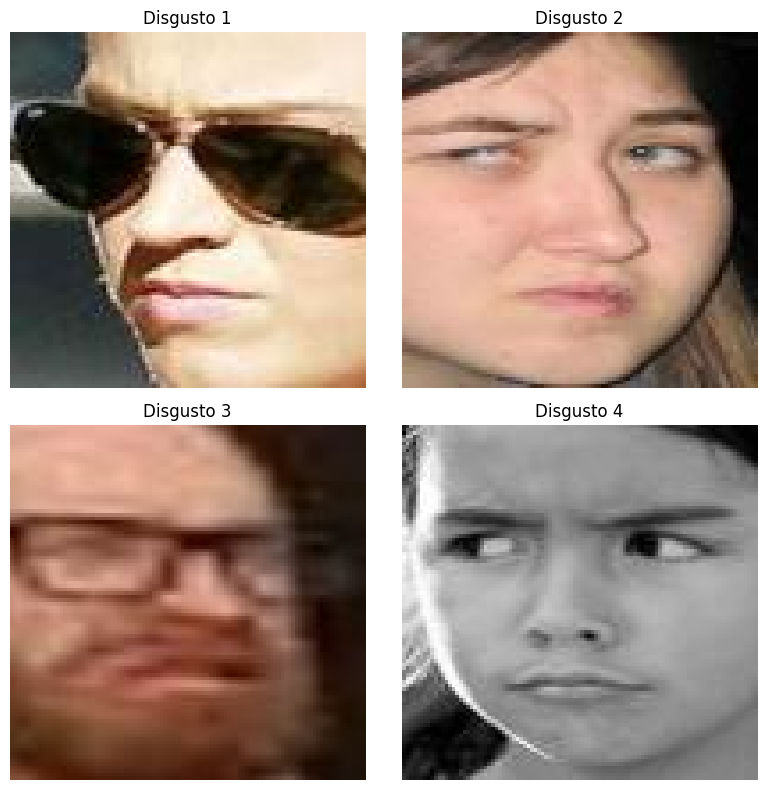

In [4]:
# VISUALIZADOR
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Clases ordenadas alfabéticamente
clases = sorted(os.listdir(DATASET_ROOT_TRAIN))

# Crear y mostrar el diccionario de opciones
diccionario_clases = {i+1: c for i, c in enumerate(clases)}
print("--- DICCIONARIO DE CLASES ---")
print("0: Aleatorio")
for k, v in diccionario_clases.items():
    print(f"{k}: {v.capitalize()}")
print("-" * 40)

# @markdown Ingresa el número de la clase que deseas visualizar:
opcion_clase = 2 # @param {type:"integer"}

if 1 <= opcion_clase <= len(clases):
    clase_seleccionada = diccionario_clases[opcion_clase]
else:
    clase_seleccionada = random.choice(clases)
    print("Opción 0 (o inválida). Clase elegida al azar.")

ruta_clase = os.path.join(DATASET_ROOT_TRAIN, clase_seleccionada)
imagenes_disponibles = [f for f in os.listdir(ruta_clase) if os.path.isfile(os.path.join(ruta_clase, f))]

if imagenes_disponibles:
    # Seleccionar hasta 4 imágenes aleatorias
    cantidad_a_mostrar = min(4, len(imagenes_disponibles))
    imagenes_random = random.sample(imagenes_disponibles, cantidad_a_mostrar)

    print(f"--- METADATA DE LAS IMÁGENES ({clase_seleccionada.upper()}) ---")

    # Crear una cuadrícula de 2x2
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    axes = axes.flatten() # Aplanar para iterar fácilmente

    for i in range(4):
        if i < cantidad_a_mostrar:
            imagen_random = imagenes_random[i]
            ruta_imagen = os.path.join(ruta_clase, imagen_random)
            img = Image.open(ruta_imagen)

            print(f"[{i+1}] Archivo: {imagen_random} | Resolución: {img.size} | Modo: {img.mode} | Formato: {img.format}")

            # Mostrar la imagen con matplotlib
            if img.mode == 'L':
                axes[i].imshow(img, cmap='gray')
            else:
                axes[i].imshow(img)

            axes[i].set_title(f"{clase_seleccionada.capitalize()} {i+1}")

        axes[i].axis('off') # Ocultar ejes incluso si no hay imagen en ese espacio

    plt.tight_layout()
    plt.show()
else:
    print(f"No se encontraron imágenes en la clase {clase_seleccionada}.")

- Imagenes de rostros en primer plano
- Todas las imágenes son 100x100 pixels, 3ch(RGB) y formato JPEG
- Algunas en escalas de grises
- Algunas con el lienzo que no es de 100*100

### 1.2 Transformaciones y Data Agumentation

In [15]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch

# 1. Definir Transformaciones y Data Augmentation (Sin Data Augmentation para corrida base)
train_transforms = transforms.Compose([
    transforms.Resize((100, 100)), # Nos aseguramos de la dimensión base
    # transforms.RandomHorizontalFlip(p=0.5), # Espejado horizontal
    # transforms.RandomRotation(degrees=10), # Rotación leve
    # transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)), # Ligeros cambios de encuadre
    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05), # Alteración de iluminación/color
    # transforms.RandomGrayscale(p=0.2), # Escala de grises ocasional
    transforms.ToTensor()          # Convertir a Tensor de PyTorch (valores entre 0.0 y 1.0)
])

test_transforms = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])

# 2. Cargar los Datasets usando ImageFolder (asume estructura de carpetas por clase)
# Usamos todo el Train original para entrenar, y el Test para testear
train_dataset = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=DATASET_ROOT_TEST, transform=test_transforms)

# 3. Crear los DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Clases mapeadas: {train_dataset.class_to_idx}")
print(f"Imágenes para entrenamiento: {len(train_dataset)} -> Batches: {len(train_loader)}")
print(f"Imágenes para test: {len(test_dataset)} -> Batches: {len(test_loader)}")


Clases mapeadas: {'alegria': 0, 'disgusto': 1, 'enojo': 2, 'miedo': 3, 'seriedad': 4, 'sorpresa': 5, 'tristeza': 6}
Imágenes para entrenamiento: 12271 -> Batches: 192
Imágenes para test: 3068 -> Batches: 48


## 2. Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional con PyTorch, **sin usar modelos pre-entrenados**.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.

In [22]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn
import torch

# Bloque de convolución para emplear en la red
def conv_block(c_in, c_out, k=3, p=1, s=1, pk=2):
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, k, padding=p, stride=s),
        nn.ReLU(),
        nn.MaxPool2d(pk)
    )

class EmotionCNN(nn.Module):
    def __init__(self, filtros=[16, 32, 64]):
        super(EmotionCNN, self).__init__()
        # La entrada es de 3 canales (RGB) y de 100x100 píxeles

        layers = []
        in_channels = 3

        # Construir dinámicamente las capas convolucionales
        for out_channels in filtros:
            layers.append(conv_block(in_channels, out_channels))
            in_channels = out_channels

        self.features = nn.Sequential(*layers)

        # Calcular automáticamente el tamaño de la imagen tras los MaxPool2d
        dim = 100
        for _ in filtros:
            dim = dim // 2

        flatten_size = filtros[-1] * dim * dim

        # Clasificador
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_size, 512),
            nn.ReLU(),
            nn.Dropout(0.5), # Dropout para reducir el overfitting
            nn.Linear(512, 7)   # 7 clases de emociones
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Calcular Pesos para Clases Desbalanceadas (Class Weights)
targets = train_dataset.targets
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(targets), y=targets)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print(f"\nModelo listo para instanciar en el dispositivo: {device}")
print("\n--- Pesos calculados por clase (Class Weights) ---")
for clase, peso in zip(train_dataset.classes, class_weights):
    print(f"{clase.capitalize()}: {peso:.4f}")



Modelo listo para instanciar en el dispositivo: cuda

--- Pesos calculados por clase (Class Weights) ---
Alegria: 0.3674
Disgusto: 2.4449
Enojo: 2.4865
Miedo: 6.2384
Seriedad: 0.6945
Sorpresa: 1.3589
Tristeza: 0.8845


In [7]:
!pip install wandb -qU

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.4/26.4 MB 23.2 MB/s eta 0:00:00


In [8]:
import wandb

# Esto te pedirá tu API key de Weights & Biases
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: amontesdeoca1982 (andresmontesdeoca) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [23]:
import time
import wandb
import torch.optim as optim
import torch.nn as nn

# Número de épocas
num_epochs = 100
patience = 5

# Batería de experimentos a ejecutar
experimentos = {
    "cw_small": [16, 32, 64],
    "cw_med": [32, 64, 128],
    "cw_high": [64, 128, 256]
}

print("Iniciando batería de experimentos de mitigación (Class Weights)...\n")

for nombre_corrida, lista_filtros in experimentos.items():
    print("="*60)
    print(f"EXPERIMENTO: {nombre_corrida} | Arquitectura: {lista_filtros}")
    print("="*60)

    # 1. Instanciar el modelo, la loss y el optimizador dinámicamente
    modelo = EmotionCNN(filtros=lista_filtros).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(modelo.parameters(), lr=0.001)

    # Listas globales que se reinician por corrida para el gráfico final
    history_train_loss = []
    history_test_loss = []
    history_train_acc = []
    history_test_acc = []

    best_test_loss = float('inf')
    epochs_no_improve = 0

    # Inicializar W&B
    wandb.init(
        project="tp3-clasificador-emociones",
        name=nombre_corrida,
        config={
            "epochs": num_epochs,
            "patience": patience,
            "learning_rate": 0.001,
            "filtros": lista_filtros,
            "batch_size": 64,
            "class_weights": True, # <-- Usamos pesos
            "data_augmentation": False
        }
    )

    for epoch in range(num_epochs):
        start_time = time.time()

        # --- FASE DE ENTRENAMIENTO ---
        modelo.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = modelo(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct_train / total_train
        history_train_loss.append(epoch_train_loss)
        history_train_acc.append(epoch_train_acc)

        # --- FASE DE TEST ---
        modelo.eval()
        running_test_loss = 0.0
        correct_test = 0
        total_test_loop = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = modelo(inputs)
                loss = criterion(outputs, labels)

                running_test_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_test_loop += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        epoch_test_loss = running_test_loss / len(test_loader.dataset)
        epoch_test_acc = correct_test / total_test_loop
        history_test_loss.append(epoch_test_loss)
        history_test_acc.append(epoch_test_acc)

        end_time = time.time()

        # Print resumido
        print(f"Ep {epoch+1:02d} | Tiempo: {end_time - start_time:.1f}s | Tr_Loss: {epoch_train_loss:.4f} | Tr_Acc: {epoch_train_acc:.4f} | Te_Loss: {epoch_test_loss:.4f} | Te_Acc: {epoch_test_acc:.4f}")

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": epoch_train_loss,
            "train_acc": epoch_train_acc,
            "test_loss": epoch_test_loss,
            "test_acc": epoch_test_acc
        })

        # --- EARLY STOPPING ---
        if epoch_test_loss < best_test_loss:
            best_test_loss = epoch_test_loss
            epochs_no_improve = 0
            torch.save(modelo.state_dict(), 'best_model.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"-> EarlyStopping disparado tras {epoch+1} épocas.")
                break

    # Cargar los mejores pesos al finalizar
    print(f"Cargando los pesos del mejor modelo para {nombre_corrida}...")
    modelo.load_state_dict(torch.load('best_model.pth'))
    wandb.finish()
    print(f"¡Entrenamiento {nombre_corrida} finalizado con éxito!\n")

print("¡TODOS LOS EXPERIMENTOS DEL BUCLE HAN FINALIZADO!")


Iniciando batería de experimentos de mitigación (Class Weights)...

EXPERIMENTO: cw_small | Arquitectura: [16, 32, 64]


Ep 01 | Tiempo: 11.1s | Tr_Loss: 1.8797 | Tr_Acc: 0.2427 | Te_Loss: 1.8491 | Te_Acc: 0.3279
Ep 02 | Tiempo: 11.1s | Tr_Loss: 1.5770 | Tr_Acc: 0.4445 | Te_Loss: 1.3011 | Te_Acc: 0.5522
Ep 03 | Tiempo: 11.1s | Tr_Loss: 1.3041 | Tr_Acc: 0.5631 | Te_Loss: 1.0757 | Te_Acc: 0.6199
Ep 04 | Tiempo: 11.1s | Tr_Loss: 1.1743 | Tr_Acc: 0.6029 | Te_Loss: 1.0642 | Te_Acc: 0.6170
Ep 05 | Tiempo: 11.1s | Tr_Loss: 1.0732 | Tr_Acc: 0.6281 | Te_Loss: 0.9750 | Te_Acc: 0.6503
Ep 06 | Tiempo: 11.3s | Tr_Loss: 0.9981 | Tr_Acc: 0.6574 | Te_Loss: 0.9704 | Te_Acc: 0.6503
Ep 07 | Tiempo: 11.1s | Tr_Loss: 0.9036 | Tr_Acc: 0.6772 | Te_Loss: 0.9596 | Te_Acc: 0.6643
Ep 08 | Tiempo: 11.1s | Tr_Loss: 0.8327 | Tr_Acc: 0.7009 | Te_Loss: 0.9457 | Te_Acc: 0.6545
Ep 09 | Tiempo: 11.0s | Tr_Loss: 0.7600 | Tr_Acc: 0.7177 | Te_Loss: 0.9258 | Te_Acc: 0.6714
Ep 10 | Tiempo: 11.0s | Tr_Loss: 0.6902 | Tr_Acc: 0.7365 | Te_Loss: 0.8817 | Te_Acc: 0.7014
Ep 11 | Tiempo: 11.0s | Tr_Loss: 0.6174 | Tr_Acc: 0.7600 | Te_Loss: 0.8886 | Te_

epoch,▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
test_acc,▁▅▆▆▇▇▇▇▇▇▇▇███▇██
test_loss,█▄▃▃▂▂▂▂▂▁▁▁▁▁▁▂▂▂
train_acc,▁▃▅▅▅▆▆▆▇▇▇▇▇▇████
train_loss,█▇▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁
epoch,18
test_acc,0.73664
test_loss,0.951
train_acc,0.8463
train_loss,0.34568


¡Entrenamiento cw_small finalizado con éxito!

EXPERIMENTO: cw_med | Arquitectura: [32, 64, 128]


Ep 01 | Tiempo: 12.6s | Tr_Loss: 1.8154 | Tr_Acc: 0.2869 | Te_Loss: 1.5671 | Te_Acc: 0.4452
Ep 02 | Tiempo: 12.5s | Tr_Loss: 1.4576 | Tr_Acc: 0.5123 | Te_Loss: 1.3110 | Te_Acc: 0.5323
Ep 03 | Tiempo: 12.5s | Tr_Loss: 1.2171 | Tr_Acc: 0.5891 | Te_Loss: 1.0344 | Te_Acc: 0.6366
Ep 04 | Tiempo: 12.5s | Tr_Loss: 1.0818 | Tr_Acc: 0.6299 | Te_Loss: 0.9665 | Te_Acc: 0.6617
Ep 05 | Tiempo: 12.5s | Tr_Loss: 0.9480 | Tr_Acc: 0.6638 | Te_Loss: 0.9056 | Te_Acc: 0.6705
Ep 06 | Tiempo: 12.5s | Tr_Loss: 0.8166 | Tr_Acc: 0.7043 | Te_Loss: 0.9127 | Te_Acc: 0.6708
Ep 07 | Tiempo: 12.4s | Tr_Loss: 0.6924 | Tr_Acc: 0.7410 | Te_Loss: 0.9180 | Te_Acc: 0.6714
Ep 08 | Tiempo: 12.4s | Tr_Loss: 0.6008 | Tr_Acc: 0.7691 | Te_Loss: 0.8525 | Te_Acc: 0.7174
Ep 09 | Tiempo: 12.4s | Tr_Loss: 0.5021 | Tr_Acc: 0.7991 | Te_Loss: 0.9088 | Te_Acc: 0.6975
Ep 10 | Tiempo: 12.4s | Tr_Loss: 0.4252 | Tr_Acc: 0.8180 | Te_Loss: 0.9113 | Te_Acc: 0.7011
Ep 11 | Tiempo: 12.4s | Tr_Loss: 0.3685 | Tr_Acc: 0.8396 | Te_Loss: 0.9431 | Te_

epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
test_acc,▁▃▆▆▇▇▇█▇▇███
test_loss,█▅▃▂▂▂▂▁▂▂▂▃▂
train_acc,▁▄▅▅▅▆▆▇▇▇███
train_loss,█▆▅▅▄▃▃▂▂▂▁▁▁
epoch,13
test_acc,0.72555
test_loss,0.99724
train_acc,0.8745
train_loss,0.26996


¡Entrenamiento cw_med finalizado con éxito!

EXPERIMENTO: cw_high | Arquitectura: [64, 128, 256]


Ep 01 | Tiempo: 17.6s | Tr_Loss: 1.8500 | Tr_Acc: 0.2832 | Te_Loss: 1.8330 | Te_Acc: 0.3201
Ep 02 | Tiempo: 17.7s | Tr_Loss: 1.5192 | Tr_Acc: 0.4712 | Te_Loss: 1.2296 | Te_Acc: 0.5825
Ep 03 | Tiempo: 17.5s | Tr_Loss: 1.2885 | Tr_Acc: 0.5648 | Te_Loss: 1.1640 | Te_Acc: 0.5971
Ep 04 | Tiempo: 17.6s | Tr_Loss: 1.1464 | Tr_Acc: 0.6108 | Te_Loss: 1.0124 | Te_Acc: 0.6454
Ep 05 | Tiempo: 17.7s | Tr_Loss: 1.0499 | Tr_Acc: 0.6336 | Te_Loss: 1.0732 | Te_Acc: 0.6027
Ep 06 | Tiempo: 17.7s | Tr_Loss: 0.9504 | Tr_Acc: 0.6625 | Te_Loss: 0.9696 | Te_Acc: 0.6431
Ep 07 | Tiempo: 17.7s | Tr_Loss: 0.8586 | Tr_Acc: 0.6914 | Te_Loss: 0.9873 | Te_Acc: 0.6450
Ep 08 | Tiempo: 17.7s | Tr_Loss: 0.7846 | Tr_Acc: 0.7139 | Te_Loss: 0.9526 | Te_Acc: 0.6565
Ep 09 | Tiempo: 17.5s | Tr_Loss: 0.6868 | Tr_Acc: 0.7396 | Te_Loss: 0.8652 | Te_Acc: 0.6956
Ep 10 | Tiempo: 17.6s | Tr_Loss: 0.5936 | Tr_Acc: 0.7633 | Te_Loss: 0.8496 | Te_Acc: 0.7080
Ep 11 | Tiempo: 17.6s | Tr_Loss: 0.5448 | Tr_Acc: 0.7787 | Te_Loss: 0.9394 | Te_

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁▆▆▇▆▇▇▇██▇████
test_loss,█▄▃▂▃▂▂▂▁▁▂▁▁▂▁
train_acc,▁▃▅▅▅▆▆▆▇▇▇▇███
train_loss,█▆▅▅▄▄▃▃▃▂▂▂▂▁▁
epoch,15
test_acc,0.72262
test_loss,0.90965
train_acc,0.84296
train_loss,0.35515


¡Entrenamiento cw_high finalizado con éxito!

¡TODOS LOS EXPERIMENTOS DEL BUCLE HAN FINALIZADO!


## 3. Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score Macro**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`.


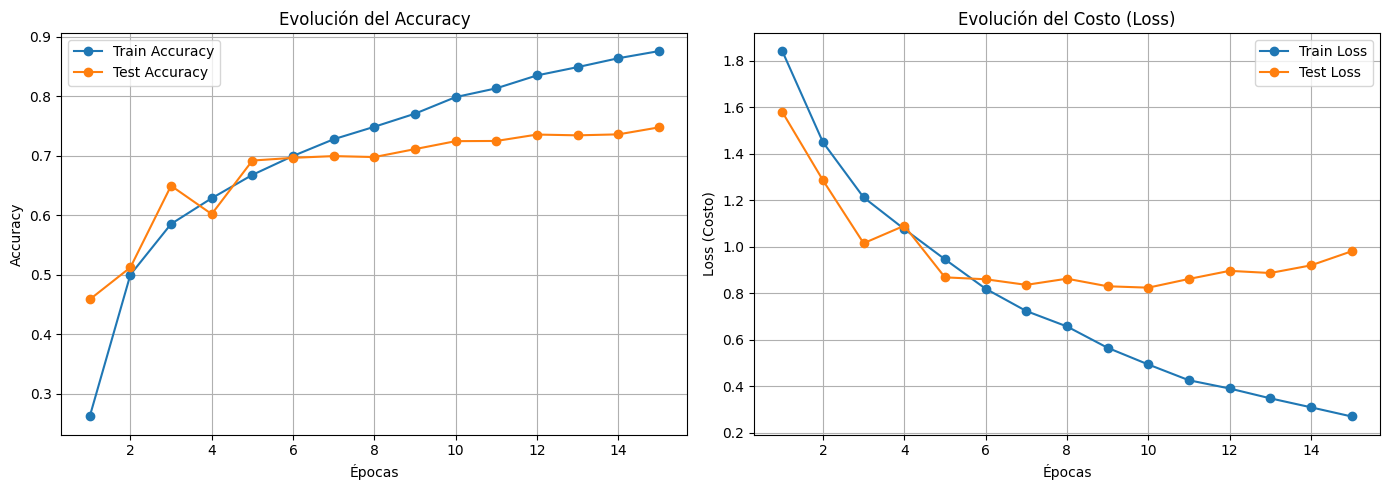

Evaluando el modelo en el conjunto de test para obtener métricas finales...
--------------------------------------------------
Accuracy Final (Test): 0.7246
F1 Score Macro Final (Test): 0.6393
--------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

     alegria       0.90      0.84      0.87      1185
    disgusto       0.34      0.52      0.41       160
       enojo       0.64      0.61      0.62       162
       miedo       0.53      0.53      0.53        74
    seriedad       0.68      0.67      0.67       680
    sorpresa       0.70      0.78      0.74       329
    tristeza       0.65      0.61      0.63       478

    accuracy                           0.72      3068
   macro avg       0.63      0.65      0.64      3068
weighted avg       0.74      0.72      0.73      3068



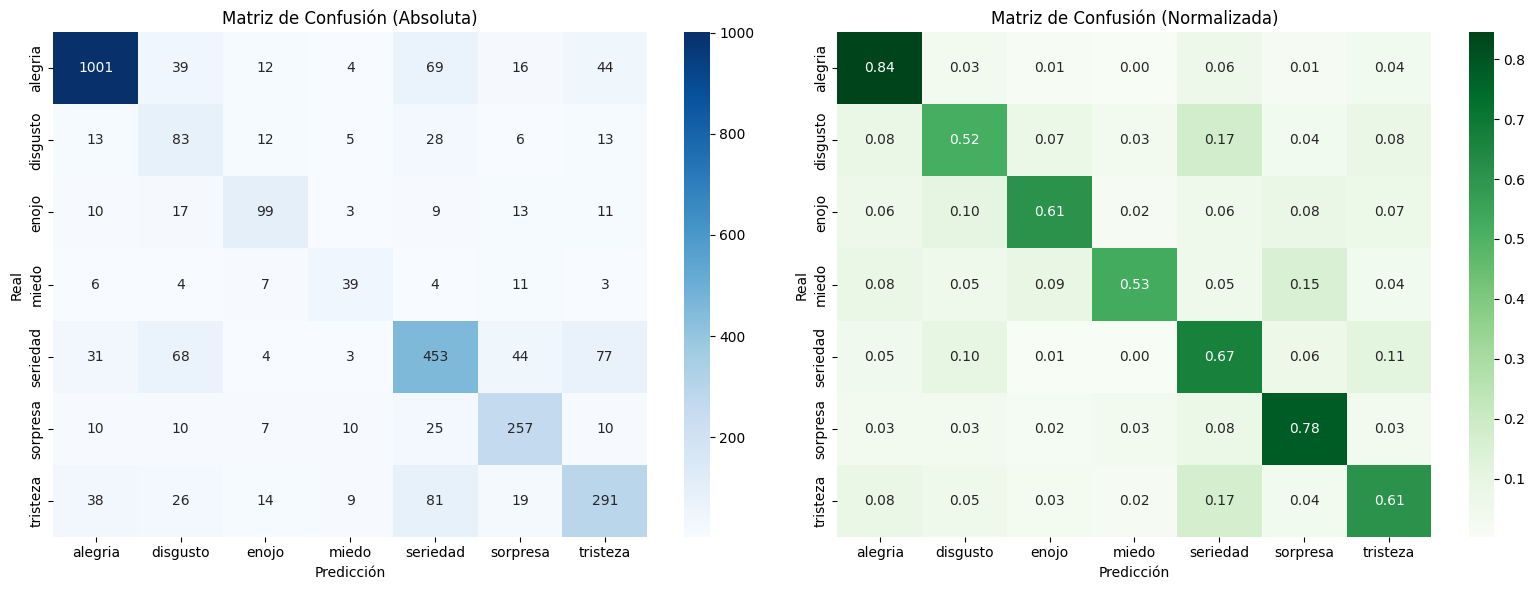

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import torch

# 1. Gráficas de Evolución (Accuracy y Loss) sobre Entrenamiento y Test
# Ajustamos el rango de épocas basado en el tamaño real del historial
actual_epochs = len(history_train_acc)
epochs_range = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de Accuracy
axes[0].plot(epochs_range, history_train_acc, label='Train Accuracy', marker='o')
axes[0].plot(epochs_range, history_test_acc, label='Test Accuracy', marker='o')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Evolución del Accuracy')
axes[0].legend()
axes[0].grid(True)

# Gráfica de Loss
axes[1].plot(epochs_range, history_train_loss, label='Train Loss', marker='o')
axes[1].plot(epochs_range, history_test_loss, label='Test Loss', marker='o')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Loss (Costo)')
axes[1].set_title('Evolución del Costo (Loss)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 2. Evaluación final en el conjunto de Test
print("Evaluando el modelo en el conjunto de test para obtener métricas finales...")
modelo.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = modelo(inputs)
        _, predicted = torch.max(outputs.data, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Nombres de las clases desde el dataset (corregido para usar train_dataset)
class_names = [c for c in train_dataset.classes]

# Calcular métricas
final_accuracy = accuracy_score(y_true, y_pred)
final_f1_macro = f1_score(y_true, y_pred, average='macro')

print("-" * 50)
print(f"Accuracy Final (Test): {final_accuracy:.4f}")
print(f"F1 Score Macro Final (Test): {final_f1_macro:.4f}")
print("-" * 50)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 3. Matrices de Confusión
cm_abs = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz Absoluta
sns.heatmap(cm_abs, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Matriz de Confusión (Absoluta)')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# Matriz Normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Matriz de Confusión (Normalizada)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()


 ## 4. Prueba de Imágenes Nuevas (1 punto)
Subir al menos 12 imágenes personales de cualquier ratio o relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación. Tampoco vale usar imágenes de otro dataset, deben ser imágenes sueltas.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones que durante el entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

 ## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 12 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase esperada
  - La clase ganadora inferida por el modelo

- Analizar los casos en los que el modelo se equivoca e intentar identificar posibles causas, tales como:

  - Similitudes entre emociones.
  - Mezcla de 2 o más emociones en una misma expresión.

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

**IMPORTANTE:** Ajusten los parámetros `scaleFactor`, `minNeighbors` y `minSize` según convenga para que la detección de rostros sea más efectiva y logre detectar rostros en sus 12 imágenes. No se queden necesariamente con los valores por defecto.